In [45]:
import pandas as pd
import numpy as np
from itertools import product


# Load the dataset
file_path = '/Users/yashaswireddy/Downloads/ca_wildfire_data.csv'
final_df_raw = pd.read_csv(file_path)

# Display the first few rows to understand the structure
final_df_raw.head()

,latitude,longitude,acq_date,satellite,instrument,confidence,year,month
0,32.539260,-117.067820,2022-02-04 00:00:00,1,VIIRS,50,2022,2
1,32.549419,-116.996498,2019-08-01 00:00:00,N,VIIRS,100,2019,8
2,32.550823,-117.004608,2019-08-01 00:00:00,N,VIIRS,50,2019,8
3,32.551083,-116.999596,2019-08-01 00:00:00,N,VIIRS,50,2019,8
4,32.551338,-116.994614,2019-08-01 00:00:00,N,VIIRS,100,2019,8


In [47]:
import pandas as pd

# Load fire data and filter years
##fire_final_df = pd.read_csv("/Users/yashaswireddy/Downloads/ca_daily_fire_2000_2025.csv")
fire_filtered = final_df_raw[(final_df_raw['year'] >= 2010) & (final_df_raw['year'] < 2024)].copy()
fire_filtered['year_month'] = pd.to_datetime(
    fire_filtered[['year', 'month']].assign(day=1)
).dt.strftime('%Y%m')

# Load weather + wind data
weather = pd.read_csv("/Users/yashaswireddy/Downloads/Precipitation_cali_data.csv")
weather = weather.drop(columns=['ANN'], errors='ignore')
weather_long = weather.melt(id_vars=['PARAMETER', 'YEAR'], var_name='month', value_name='value')
month_map = {'JAN': '01','FEB': '02','MAR': '03','APR': '04','MAY': '05','JUN': '06',
             'JUL': '07','AUG': '08','SEP': '09','OCT': '10','NOV': '11','DEC': '12'}
weather_long['month'] = weather_long['month'].map(month_map)
weather_long['year_month'] = weather_long['YEAR'].astype(str) + weather_long['month']
weather_wide = weather_long.pivot_table(index='year_month', columns='PARAMETER', values='value').reset_index()

# Load NDVI data and rescale
ndvi = pd.read_csv("/Users/yashaswireddy/Downloads/Monthly_NDVI_California_2010_2025.csv")
ndvi_cleaned = ndvi[['year_month', 'NDVI']].copy()
ndvi_cleaned['NDVI'] = ndvi_cleaned['NDVI'] / 10000

# Load temperature data
temp_final_df = pd.read_excel("/Users/yashaswireddy/Downloads/Temperature_cali_monthly.xlsx")
temp_final_df = temp_final_df.drop(columns=['ANN'], errors='ignore')
temp_long = temp_final_df.melt(id_vars=['PARAMETER', 'YEAR'], var_name='month', value_name='value')
temp_long['month'] = temp_long['month'].map(month_map)
temp_long['year_month'] = temp_long['YEAR'].astype(str) + temp_long['month']
temp_wide = temp_long.pivot_table(index='year_month', columns='PARAMETER', values='value').reset_index()

# Load elevation/slope/aspect data
elevation_final_df = pd.read_csv("/Users/yashaswireddy/Downloads/California_Elevation_Slope_Aspect.csv")
elevation = elevation_final_df['elevation'].iloc[0]
slope = elevation_final_df['slope'].iloc[0]
aspect = elevation_final_df['aspect'].iloc[0]

#Convert all year_months to string before merging
fire_filtered['year_month'] = fire_filtered['year_month'].astype(str)
weather_wide['year_month'] = weather_wide['year_month'].astype(str)
ndvi_cleaned['year_month'] = ndvi_cleaned['year_month'].astype(str)
temp_wide['year_month'] = temp_wide['year_month'].astype(str)

# Merge all datasets
final_df = pd.merge(fire_filtered, weather_wide, on='year_month', how='left')
final_df = pd.merge(final_df, ndvi_cleaned, on='year_month', how='left')
final_df = pd.merge(final_df, temp_wide, on='year_month', how='left')

# Add terrain features to all rows
final_df['elevation'] = elevation
final_df['slope'] = slope
final_df['aspect'] = aspect

# Preview the final dataset
print(final_df.head())


    latitude   longitude             acq_date satellite instrument  \
0  32.539260 -117.067820  2022-02-04 00:00:00         1      VIIRS   
1  32.549419 -116.996498  2019-08-01 00:00:00         N      VIIRS   
2  32.550823 -117.004608  2019-08-01 00:00:00         N      VIIRS   
3  32.551083 -116.999596  2019-08-01 00:00:00         N      VIIRS   
4  32.551338 -116.994614  2019-08-01 00:00:00         N      VIIRS   

   confidence  year  month year_month  PRECTOTCORR  ...   RH2M  WD10M  \
0          50  2022      2     202202         0.19  ...  52.58   69.4   
1         100  2019      8     201908         0.01  ...  24.62  242.5   
2          50  2019      8     201908         0.01  ...  24.62  242.5   
3          50  2019      8     201908         0.01  ...  24.62  242.5   
4         100  2019      8     201908         0.01  ...  24.62  242.5   

   WS10M_RANGE      NDVI    T2M  T2M_MAX     TS    elevation     slope  \
0         6.19  0.284142   7.75    23.53   6.08  1006.472224  3.25

In [49]:
final_df['year'].unique().tolist()

[2022,
 2019,
 2012,
 2020,
 2015,
 2021,
 2016,
 2014,
 2018,
 2017,
 2013,
 2010,
 2011,
 2023]

In [51]:
# Drop all rows where confidence is below 50%
final_df = final_df[final_df['confidence'] > 50]

In [53]:
final_df['latitude'] = final_df['latitude'].round(2)
final_df['longitude'] = final_df['longitude'].round(2)

# Group and aggregate
grouped_final_df = final_df.groupby(['latitude', 'longitude', 'year', 'month']).agg(
    fire_count=('confidence', 'count'),
    avg_confidence=('confidence', 'mean'),
    PRECTOTCORR=('PRECTOTCORR', 'median'),
    PRECTOTCORR_SUM=('PRECTOTCORR_SUM', 'mean'),
    RH2M=('RH2M', 'mean'),
    WD10M=('WD10M', 'median'),
    WS10M_RANGE=('WS10M_RANGE', 'mean'),
    NDVI=('NDVI', 'mean'),
    T2M=('T2M', 'mean'),
    T2M_MAX=('T2M_MAX', 'mean'),
    TS=('TS', 'mean'),
    elevation=('elevation', 'mean'),
    slope=('slope', 'mean'),
    aspect=('aspect', 'mean')
).reset_index()

# Final result
final_df = grouped_final_df.copy()

In [55]:
#creating a target variable 
final_df['fire_occurred'] = (
    (final_df['fire_count'] > 1) & 
    (final_df['avg_confidence'] >= 70)
).astype(int)


In [57]:
final_df['fire_risk_index'] = (0.4*final_df['T2M_MAX'] + 
                              0.3*(100 - final_df['RH2M']) + 
                              0.3*(1/(final_df['PRECTOTCORR']+0.1)))

TARGET VARIABLE ANALYSIS
Class distribution:
fire_occurred
0    48292
1    39347
Name: count, dtype: int64
Percentage of fire occurrences: 44.89667841942514 %


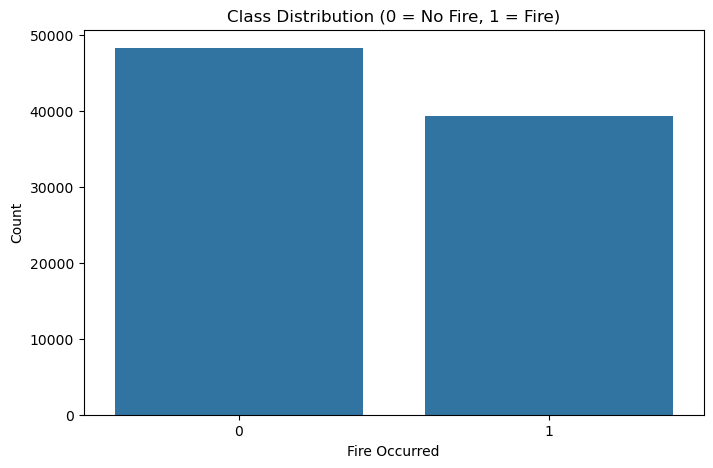


Missing values in features:
latitude           0
longitude          0
year               0
month              0
PRECTOTCORR        0
PRECTOTCORR_SUM    0
RH2M               0
WD10M              0
WS10M_RANGE        0
NDVI               0
T2M                0
T2M_MAX            0
TS                 0
elevation          0
slope              0
aspect             0
fire_risk_index    0
month_sin          0
month_cos          0
dtype: int64

Feature Correlation Analysis


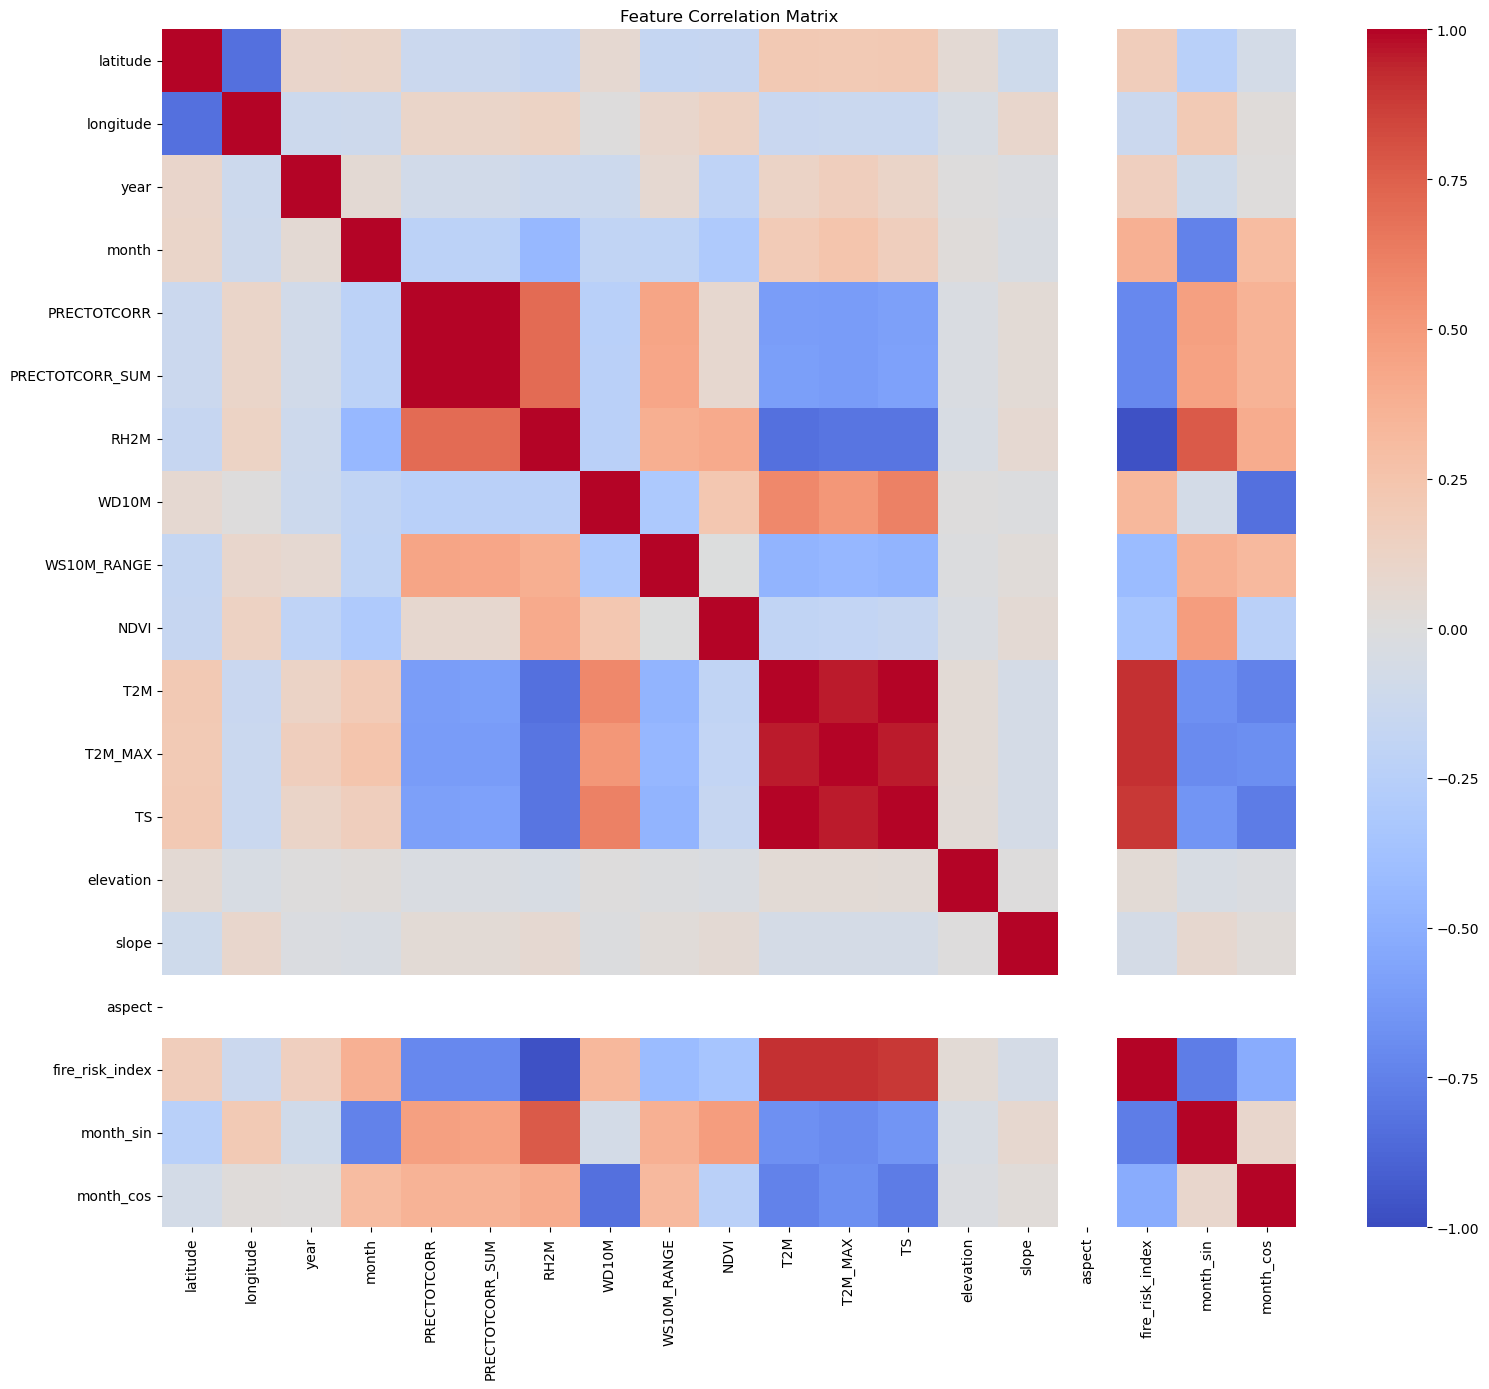


Highly correlated features:
latitude is highly correlated with: longitude
longitude is highly correlated with: latitude
PRECTOTCORR is highly correlated with: PRECTOTCORR_SUM
PRECTOTCORR_SUM is highly correlated with: PRECTOTCORR
RH2M is highly correlated with: T2M, T2M_MAX, TS, fire_risk_index
WD10M is highly correlated with: month_cos
T2M is highly correlated with: RH2M, T2M_MAX, TS, fire_risk_index
T2M_MAX is highly correlated with: RH2M, T2M, TS, fire_risk_index
TS is highly correlated with: RH2M, T2M, T2M_MAX, fire_risk_index
fire_risk_index is highly correlated with: RH2M, T2M, T2M_MAX, TS
month_cos is highly correlated with: WD10M

Logistic Regression Performance:
Accuracy: 0.6674
Precision: 0.5978
Recall: 0.7924
F1 Score: 0.6814
AUC: 0.7171

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.57      0.65     14488
           1       0.60      0.79      0.68     11804

    accuracy                           0.67     2629

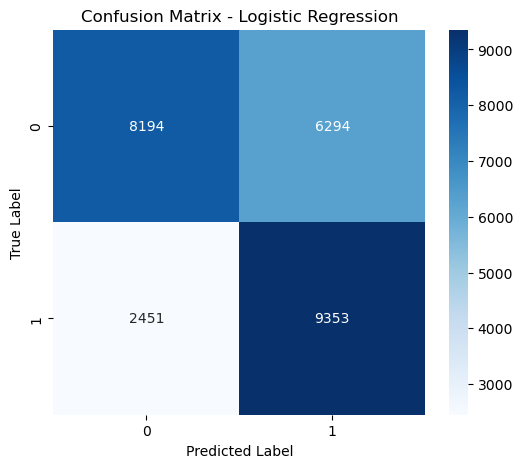

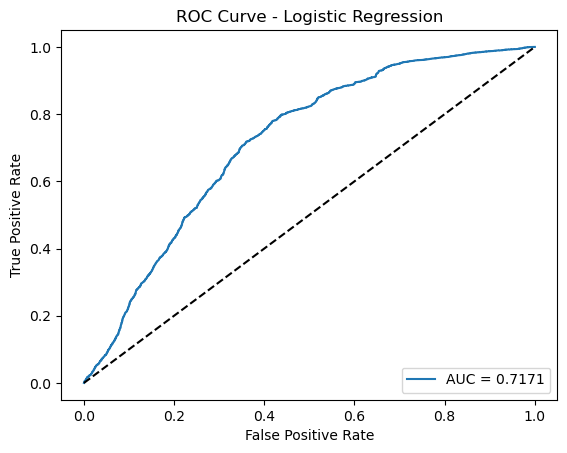


Random Forest Performance:
Accuracy: 0.7278
Precision: 0.6854
Recall: 0.7275
F1 Score: 0.7059
AUC: 0.8032

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.73      0.75     14488
           1       0.69      0.73      0.71     11804

    accuracy                           0.73     26292
   macro avg       0.73      0.73      0.73     26292
weighted avg       0.73      0.73      0.73     26292



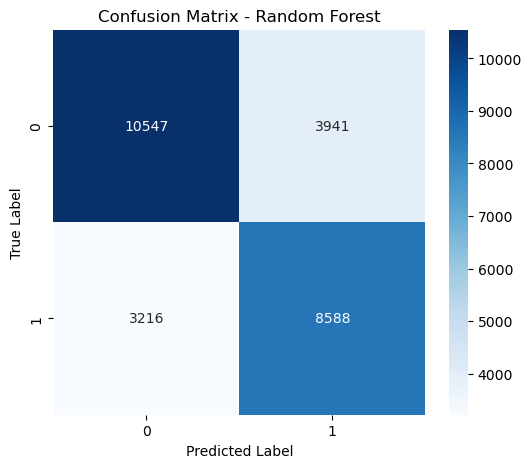

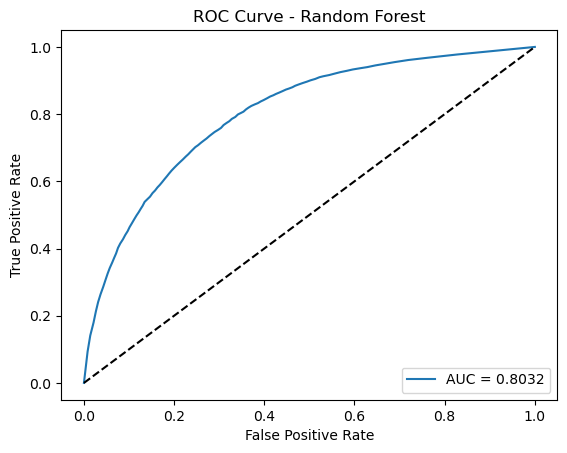

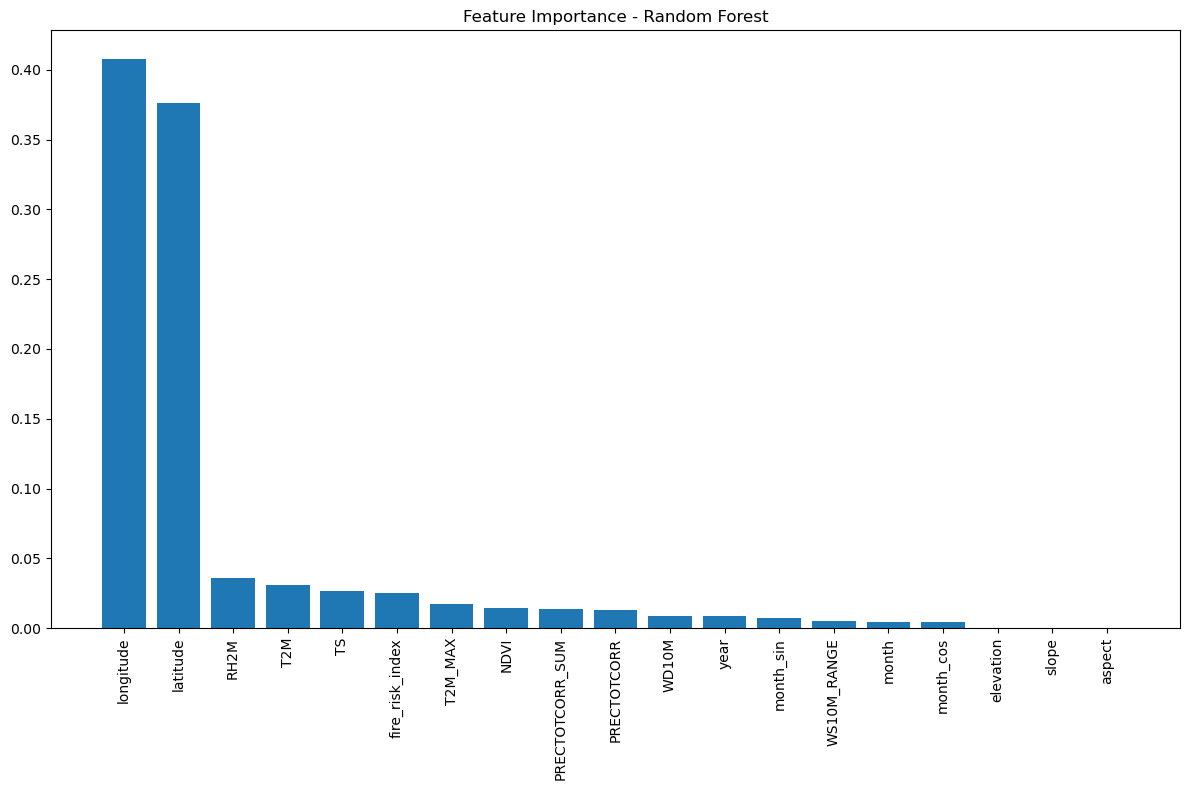


Top 10 Important Features:
longitude: 0.4078
latitude: 0.3763
RH2M: 0.0359
T2M: 0.0306
TS: 0.0264
fire_risk_index: 0.0252
T2M_MAX: 0.0175
NDVI: 0.0143
PRECTOTCORR_SUM: 0.0135
PRECTOTCORR: 0.0130

Gradient Boosting Performance:
Accuracy: 0.7087
Precision: 0.6470
Recall: 0.7725
F1 Score: 0.7042
AUC: 0.7725

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.66      0.71     14488
           1       0.65      0.77      0.70     11804

    accuracy                           0.71     26292
   macro avg       0.71      0.71      0.71     26292
weighted avg       0.72      0.71      0.71     26292



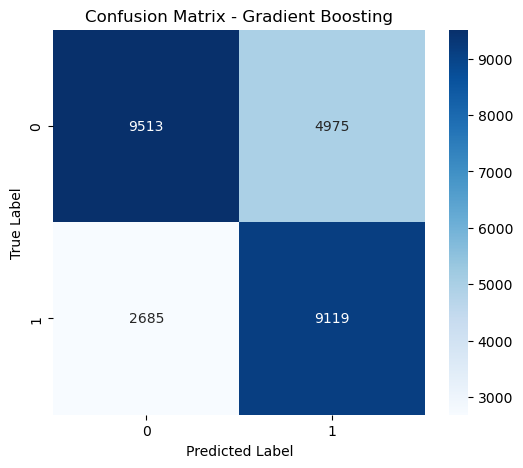

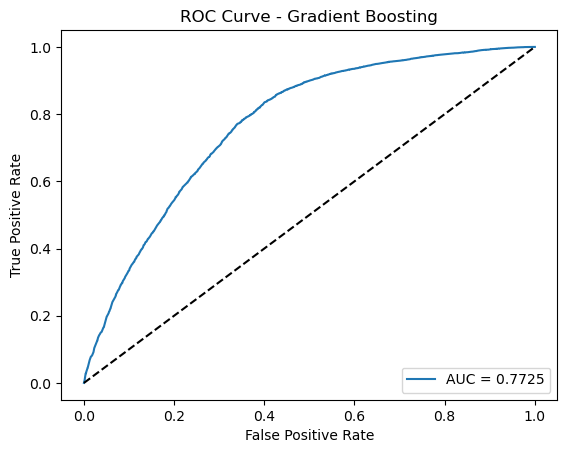

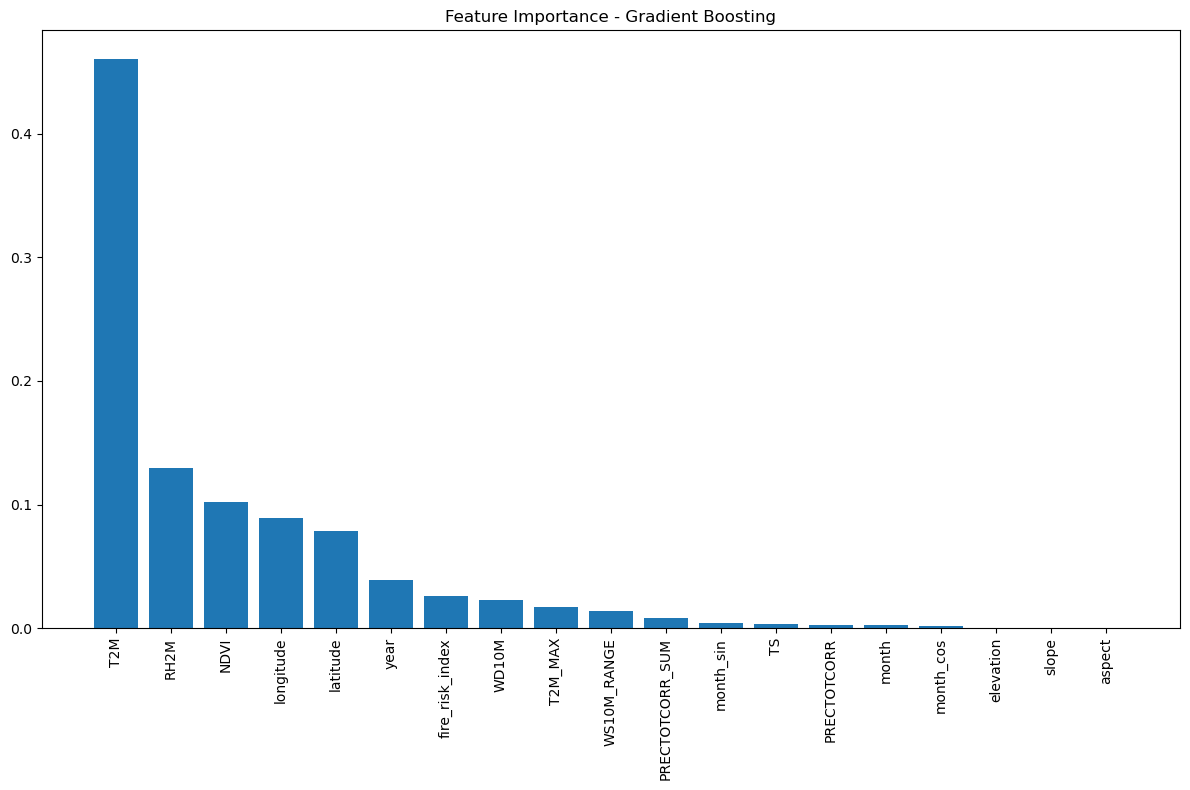


Top 10 Important Features:
T2M: 0.4605
RH2M: 0.1294
NDVI: 0.1020
longitude: 0.0887
latitude: 0.0782
year: 0.0393
fire_risk_index: 0.0257
WD10M: 0.0231
T2M_MAX: 0.0167
WS10M_RANGE: 0.0137

Support Vector Machine Performance:
Accuracy: 0.6897
Precision: 0.6147
Recall: 0.8273
F1 Score: 0.7054
AUC: 0.7478

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.58      0.67     14488
           1       0.61      0.83      0.71     11804

    accuracy                           0.69     26292
   macro avg       0.71      0.70      0.69     26292
weighted avg       0.72      0.69      0.69     26292



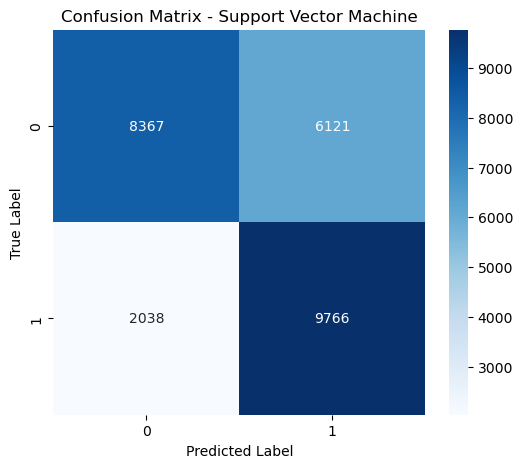

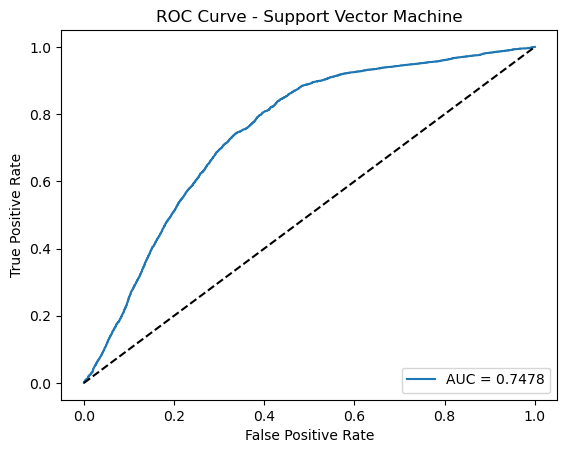


XGBoost Performance:
Accuracy: 0.7198
Precision: 0.6441
Recall: 0.8405
F1 Score: 0.7293
AUC: 0.7915

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.62      0.71     14488
           1       0.64      0.84      0.73     11804

    accuracy                           0.72     26292
   macro avg       0.74      0.73      0.72     26292
weighted avg       0.74      0.72      0.72     26292



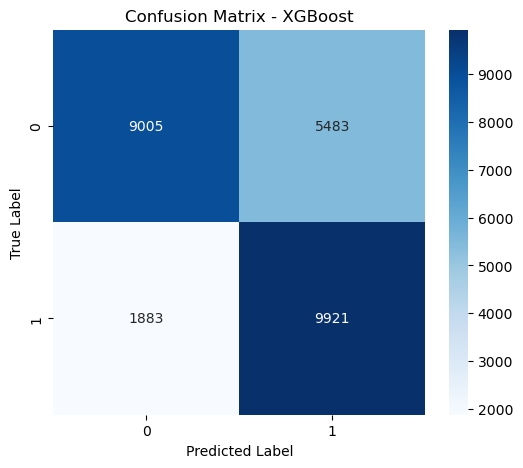

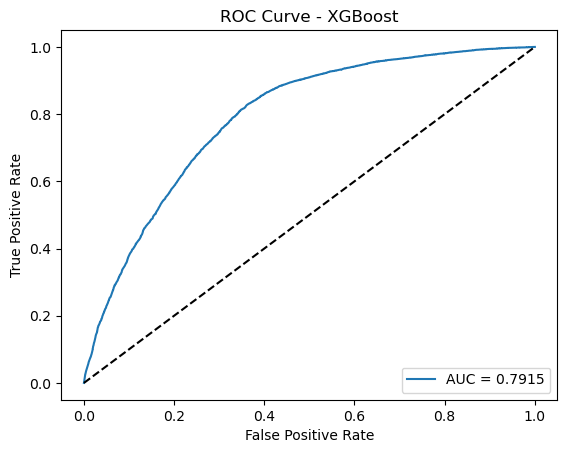

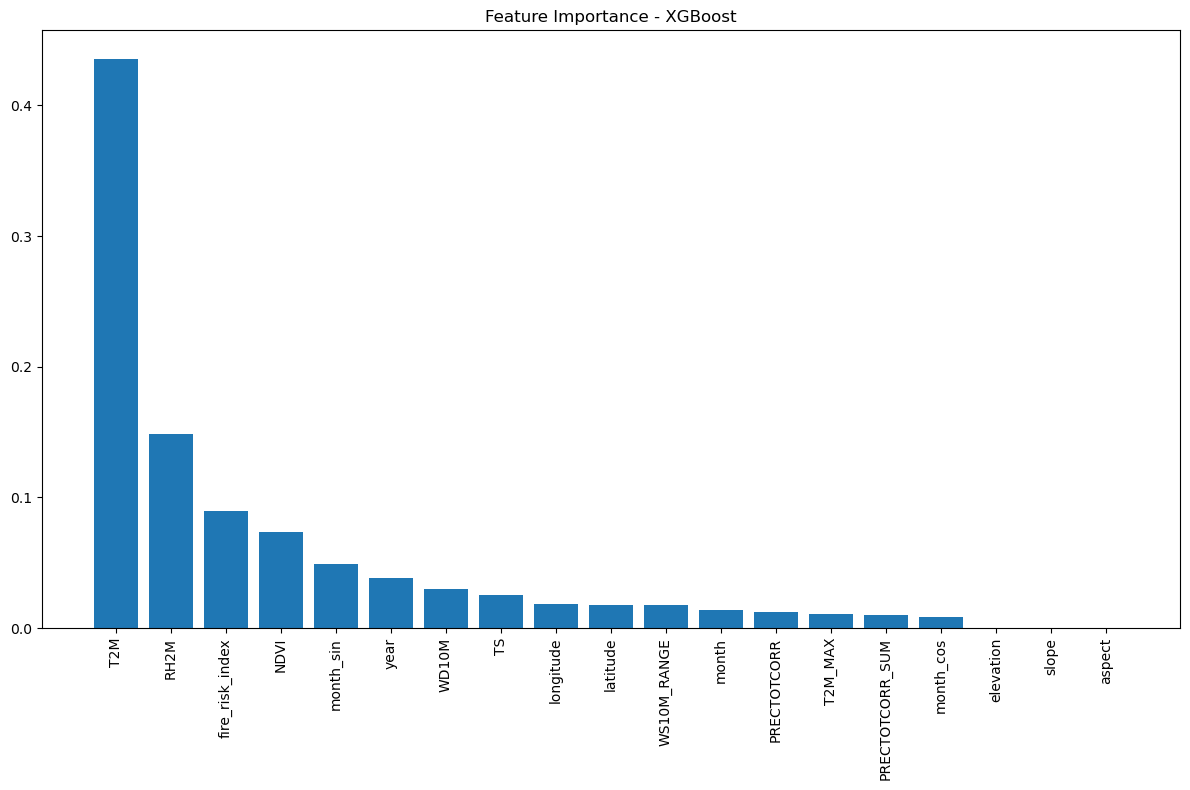


Top 10 Important Features:
T2M: 0.4357
RH2M: 0.1485
fire_risk_index: 0.0893
NDVI: 0.0734
month_sin: 0.0494
year: 0.0381
WD10M: 0.0298
TS: 0.0254
longitude: 0.0185
latitude: 0.0179
[LightGBM] [Info] Number of positive: 27543, number of negative: 33804
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000399 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2136
[LightGBM] [Info] Number of data points in the train set: 61347, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000

LightGBM Performance:
Accuracy: 0.7252
Precision: 0.6495
Recall: 0.8430
F1 Score: 0.7337
AUC: 0.7973

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.63      0.72     14488
           1       0.65     

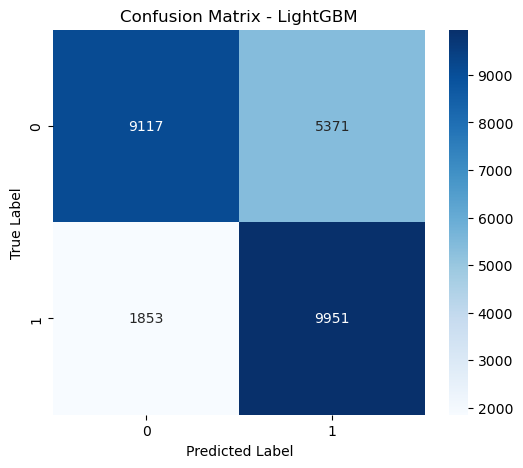

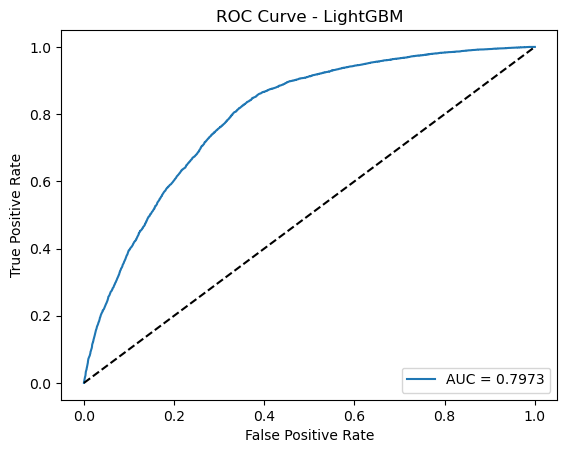

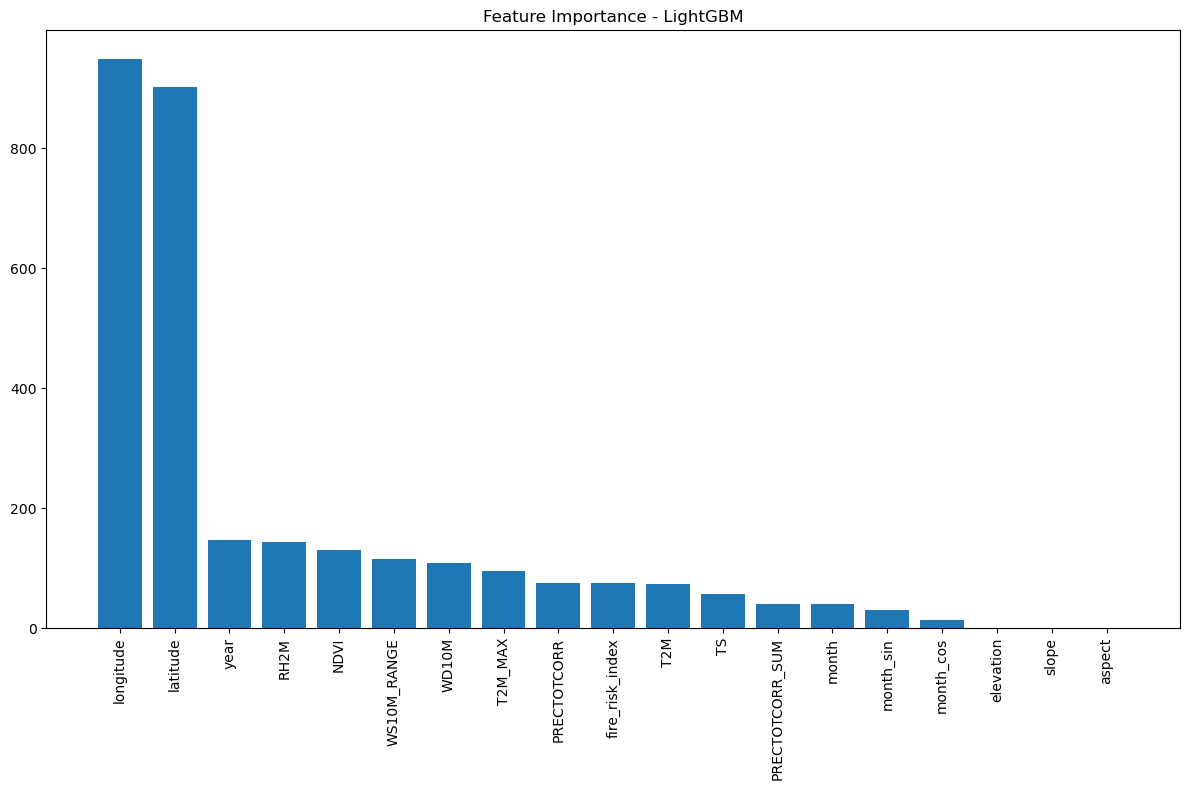


Top 10 Important Features:
longitude: 949.0000
latitude: 902.0000
year: 147.0000
RH2M: 143.0000
NDVI: 131.0000
WS10M_RANGE: 116.0000
WD10M: 108.0000
T2M_MAX: 95.0000
PRECTOTCORR: 76.0000
fire_risk_index: 76.0000

HYPERPARAMETER TUNING

Tuning XGBoost...
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Tuned XGBoost Performance:
Accuracy: 0.7335
Precision: 0.6613
Recall: 0.8331
F1 Score: 0.7373
AUC: 0.8080

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.65      0.73     14488
           1       0.66      0.83      0.74     11804

    accuracy                           0.73     26292
   macro avg       0.74      0.74      0.73     26292
weighted avg       0.75      0.73      0.73     26292



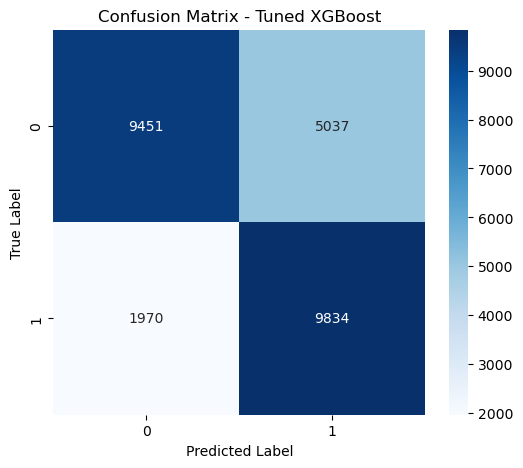

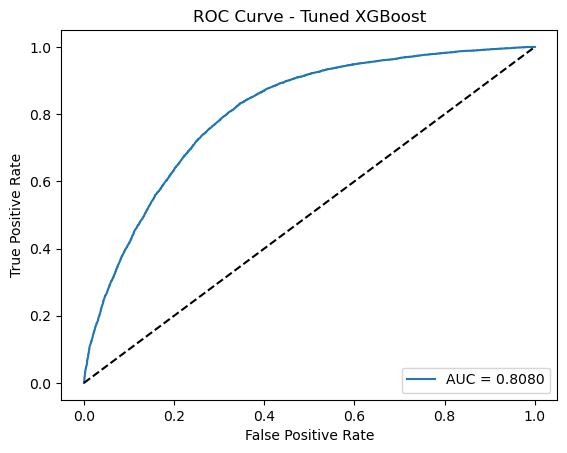

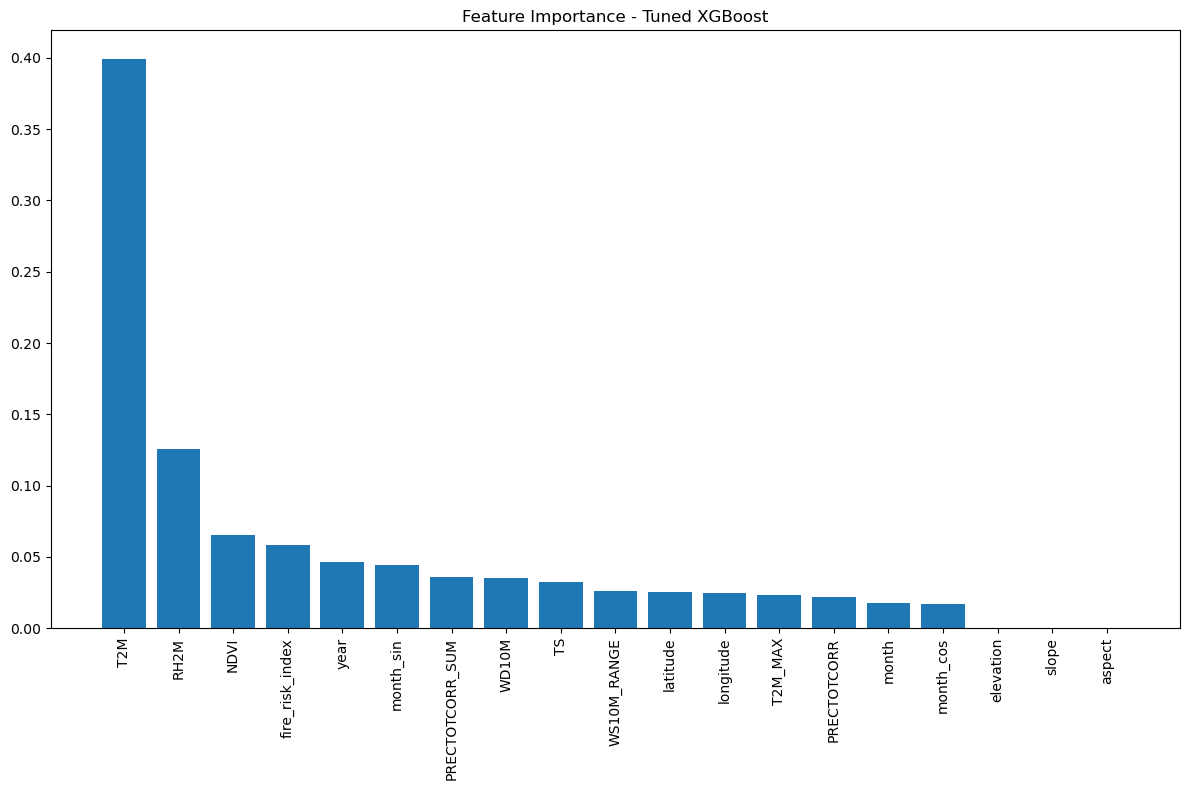


Top 10 Important Features:
T2M: 0.3993
RH2M: 0.1258
NDVI: 0.0653
fire_risk_index: 0.0587
year: 0.0465
month_sin: 0.0444
PRECTOTCORR_SUM: 0.0356
WD10M: 0.0354
TS: 0.0326
WS10M_RANGE: 0.0259

Tuning Random Forest...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Tuned Random Forest Performance:
Accuracy: 0.7411
Precision: 0.6810
Recall: 0.7964
F1 Score: 0.7342
AUC: 0.8172

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.70      0.75     14488
           1       0.68      0.80      0.73     11804

    accuracy                           0.74     26292
   macro avg       0.74      0.75      0.74     26292
weighted avg       0.75      0.74      0.74     26292



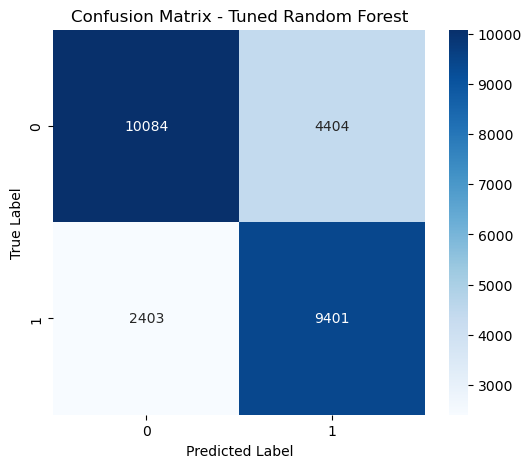

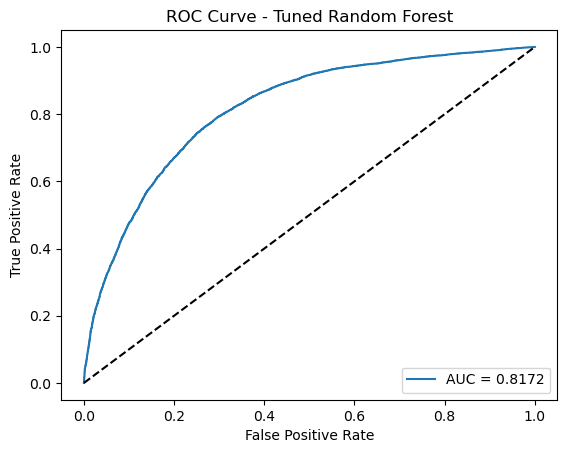

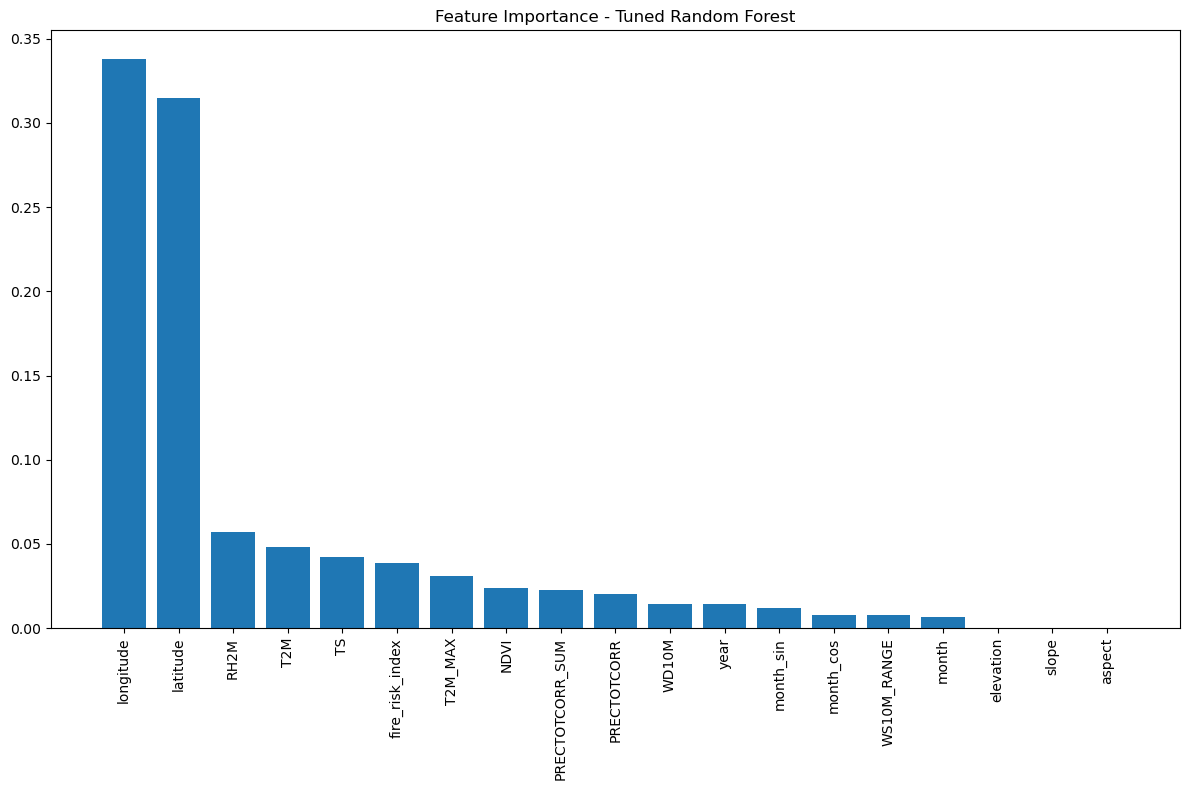


Top 10 Important Features:
longitude: 0.3381
latitude: 0.3150
RH2M: 0.0569
T2M: 0.0482
TS: 0.0425
fire_risk_index: 0.0385
T2M_MAX: 0.0309
NDVI: 0.0237
PRECTOTCORR_SUM: 0.0226
PRECTOTCORR: 0.0203

MODEL COMPARISON
                        accuracy  precision    recall        f1       auc
model                                                                    
Tuned XGBoost           0.733493   0.661287  0.833107  0.737320  0.808032
Tuned Random Forest     0.741100   0.680985  0.796425  0.734195  0.817190
LightGBM                0.725240   0.649458  0.843019  0.733687  0.797339
XGBoost                 0.719839   0.644053  0.840478  0.729271  0.791479
Random Forest           0.727788   0.685450  0.727550  0.705873  0.803189
Support Vector Machine  0.689677   0.614716  0.827347  0.705356  0.747847
Gradient Boosting       0.708657   0.647013  0.772535  0.704224  0.772513
Logistic Regression     0.667389   0.597750  0.792359  0.681432  0.717126


<Figure size 1400x800 with 0 Axes>

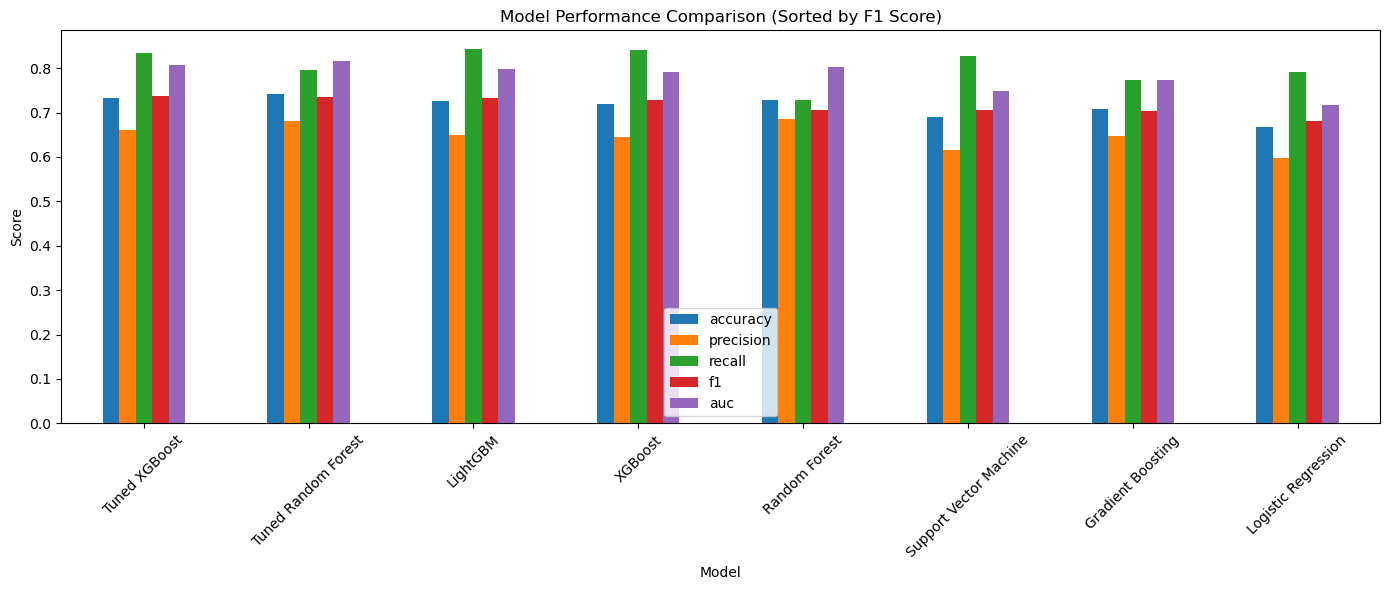


FEATURE IMPORTANCE ANALYSIS

Top features common to both Random Forest and XGBoost:
- month_sin
- latitude
- RH2M
- T2M
- TS
- year
- fire_risk_index
- WD10M
- PRECTOTCORR_SUM
- T2M_MAX
- PRECTOTCORR
- longitude
- NDVI
- WS10M_RANGE


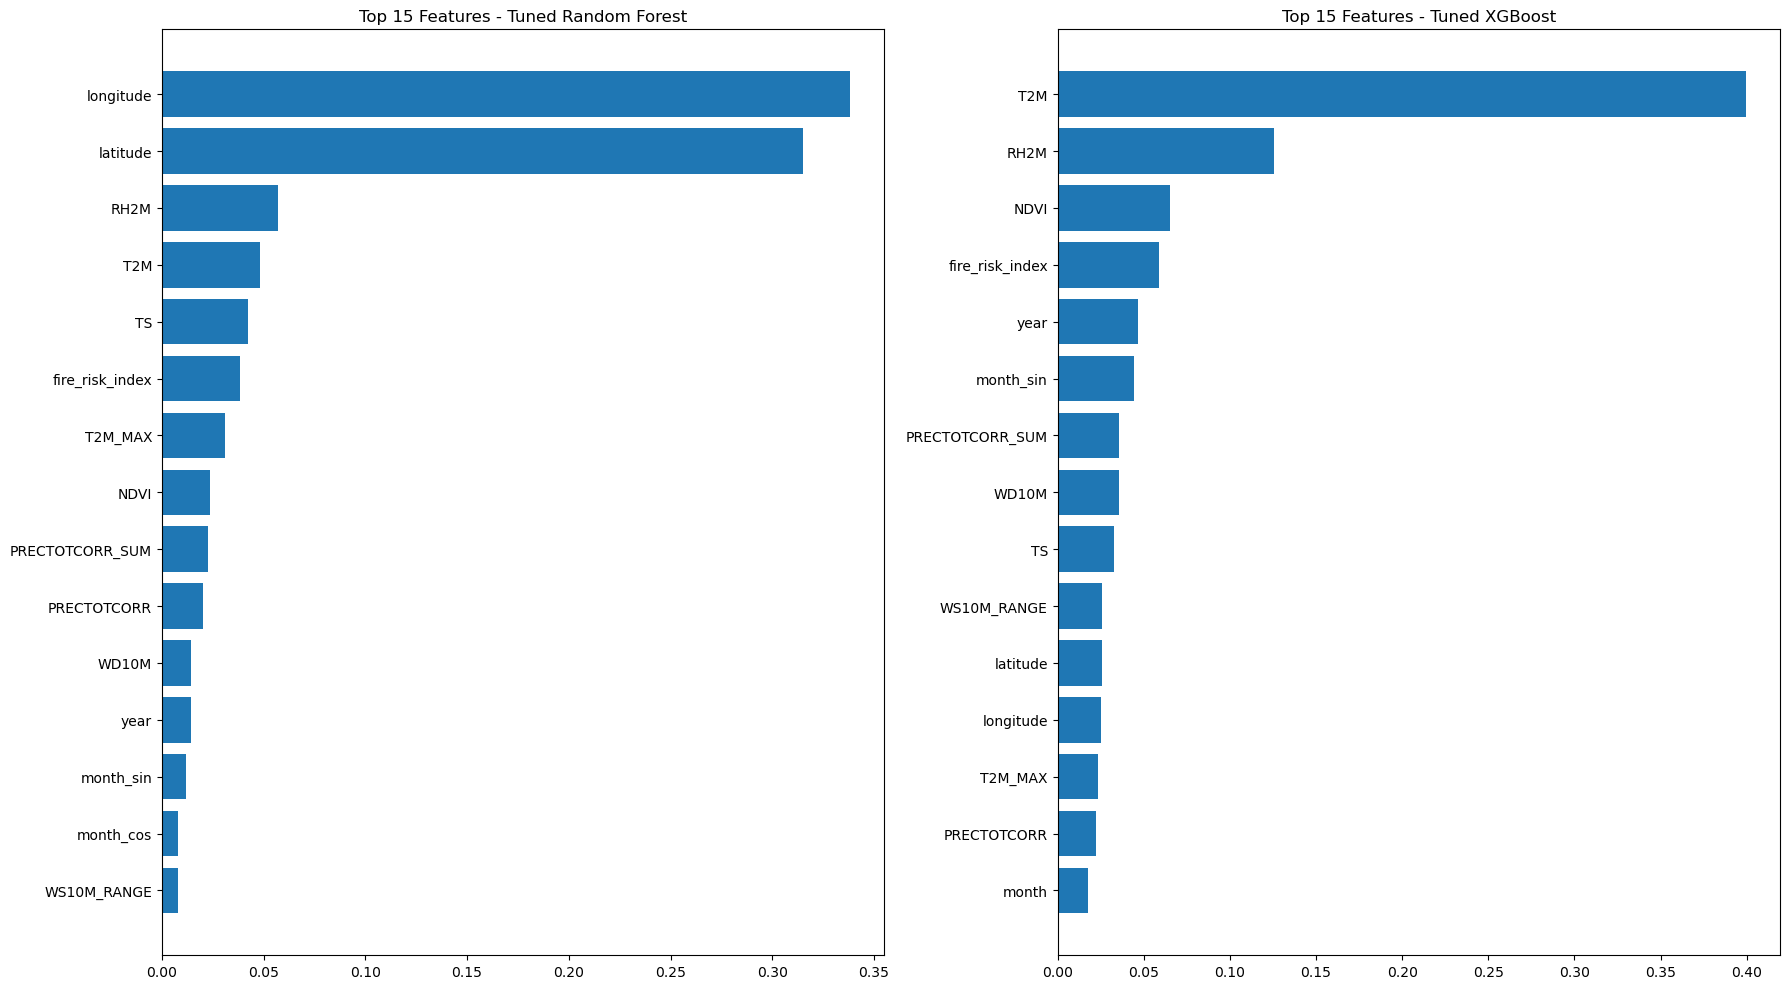


FINAL RECOMMENDATIONS

The best performing model is: Tuned XGBoost

Key Recommendations:
1. Focus on the most important features identified by the models to simplify the model
2. Consider collecting more data if the class imbalance is severe
3. For operational use, deploy the model with the highest F1 score (best balance between precision and recall)
4. Monitor model performance over time as environmental conditions change
5. Consider creating an ensemble of the top performing models

Results saved to 'wildfire_prediction_model_results.csv'


In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score, classification_report
import xgboost as xgb
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings('ignore')

# Load your data (uncomment and modify this line)
# final_df = pd.read_csv('your_data.csv')

# First, let's understand our target variable
print("="*50)
print("TARGET VARIABLE ANALYSIS")
print("="*50)
print("Class distribution:")
print(final_df['fire_occurred'].value_counts())
print("Percentage of fire occurrences:", final_df['fire_occurred'].mean() * 100, "%")

# Visualize the class distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='fire_occurred', data=final_df)
plt.title('Class Distribution (0 = No Fire, 1 = Fire)')
plt.xlabel('Fire Occurred')
plt.ylabel('Count')
plt.show()

# Feature selection - exclude target and direct indicators
# We'll keep all features except those directly related to fires
features = final_df.drop(['fire_occurred', 'fire_count', 'avg_confidence'], axis=1)
target = final_df['fire_occurred']

# Add cyclical month features to capture seasonality
features['month_sin'] = np.sin(2 * np.pi * features['month'] / 12)
features['month_cos'] = np.cos(2 * np.pi * features['month'] / 12)

# Check for missing values
print("\nMissing values in features:")
print(features.isnull().sum())

# Feature correlation analysis
print("\nFeature Correlation Analysis")
plt.figure(figsize=(16, 14))
correlation_matrix = features.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Identify highly correlated features (|correlation| > 0.8)
high_corr = (correlation_matrix.abs() > 0.8) & (correlation_matrix != 1.0)
high_corr_features = []
for col in high_corr.columns:
    high_corr_pairs = high_corr[col][high_corr[col]].index.tolist()
    if high_corr_pairs:
        high_corr_features.append((col, high_corr_pairs))
print("\nHighly correlated features:")
for feature, corr_with in high_corr_features:
    print(f"{feature} is highly correlated with: {', '.join(corr_with)}")

# Based on correlation, we might want to remove some features
# For this analysis, we'll keep all features but note that in production you might want to remove some

# Split data into training and test sets (70% training, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    features, 
    target, 
    test_size=0.3, 
    random_state=42, 
    stratify=target
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Function to evaluate and display model results
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, use_scaled=False):
    # Use scaled data if requested
    X_train_data = X_train_scaled if use_scaled else X_train
    X_test_data = X_test_scaled if use_scaled else X_test
    
    # Fit the model
    model.fit(X_train_data, y_train)
    
    # Predict on test data
    y_pred = model.predict(X_test_data)
    y_pred_proba = model.predict_proba(X_test_data)[:, 1] if hasattr(model, "predict_proba") else None
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None
    
    # Classification report
    print(f"\n{model_name} Performance:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    if auc is not None:
        print(f"AUC: {auc:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # Confusion Matrix
    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    # ROC Curve
    if y_pred_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        plt.figure()
        plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve - {model_name}')
        plt.legend(loc='lower right')
        plt.show()
    
    # Feature importance if available
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        indices = np.argsort(importances)[::-1]
        
        plt.figure(figsize=(12, 8))
        plt.title(f'Feature Importance - {model_name}')
        plt.bar(range(X_train.shape[1]), importances[indices])
        plt.xticks(range(X_train.shape[1]), X_train.columns[indices], rotation=90)
        plt.tight_layout()
        plt.show()
        
        print("\nTop 10 Important Features:")
        for f in range(min(10, X_train.shape[1])):
            print(f"{X_train.columns[indices[f]]}: {importances[indices[f]]:.4f}")
    
    return {
        'model': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc if auc is not None else np.nan
    }

# Initialize models with class weighting for imbalance
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Support Vector Machine": SVC(probability=True, class_weight='balanced', random_state=42),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        objective='binary:logistic',
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        random_state=42
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=100,
        learning_rate=0.1,
        class_weight='balanced',
        random_state=42
    )
}

# Evaluate all models
results = []
for name, model in models.items():
    use_scaled = name in ["Logistic Regression", "Support Vector Machine"]
    results.append(evaluate_model(model, X_train, X_test, y_train, y_test, name, use_scaled=use_scaled))

# Hyperparameter tuning for best performing models
print("\n" + "="*50)
print("HYPERPARAMETER TUNING")
print("="*50)

# Tune XGBoost
print("\nTuning XGBoost...")
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    xgb.XGBClassifier(
        objective='binary:logistic',
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        random_state=42
    ),
    param_grid=xgb_param_grid,
    cv=5,
    scoring='f1',
    verbose=1,
    n_jobs=-1
)
xgb_grid.fit(X_train, y_train)
best_xgb = xgb_grid.best_estimator_
results.append(evaluate_model(best_xgb, X_train, X_test, y_train, y_test, "Tuned XGBoost"))

# Tune Random Forest
print("\nTuning Random Forest...")
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid=rf_param_grid,
    cv=5,
    scoring='f1',
    verbose=1,
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
results.append(evaluate_model(best_rf, X_train, X_test, y_train, y_test, "Tuned Random Forest"))

# Compare all models
results_df = pd.DataFrame(results)
results_df = results_df.set_index('model')

print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)
print(results_df.sort_values('f1', ascending=False))

# Visualize model comparison
plt.figure(figsize=(14, 8))
results_df.sort_values('f1', ascending=False).plot(kind='bar', figsize=(14, 6))
plt.title('Model Performance Comparison (Sorted by F1 Score)')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend(loc='best')
plt.show()

# Feature importance comparison between best models
print("\n" + "="*50)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*50)

if hasattr(best_rf, 'feature_importances_') and hasattr(best_xgb, 'feature_importances_'):
    # Get top 15 features from each model
    rf_importances = best_rf.feature_importances_
    rf_indices = np.argsort(rf_importances)[-15:]
    
    xgb_importances = best_xgb.feature_importances_
    xgb_indices = np.argsort(xgb_importances)[-15:]
    
    # Find common important features
    common_features = list(set([features.columns[i] for i in rf_indices]).intersection(
        [features.columns[i] for i in xgb_indices]))
    
    print("\nTop features common to both Random Forest and XGBoost:")
    for feature in common_features:
        print(f"- {feature}")
    
    # Create comparison plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 10))
    
    # Random Forest
    y_pos = np.arange(len(rf_indices))
    ax1.barh(y_pos, rf_importances[rf_indices])
    ax1.set_yticks(y_pos)
    ax1.set_yticklabels([features.columns[i] for i in rf_indices])
    ax1.set_title('Top 15 Features - Tuned Random Forest')
    
    # XGBoost
    y_pos = np.arange(len(xgb_indices))
    ax2.barh(y_pos, xgb_importances[xgb_indices])
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels([features.columns[i] for i in xgb_indices])
    ax2.set_title('Top 15 Features - Tuned XGBoost')
    
    plt.tight_layout()
    plt.show()

# Final recommendations
print("\n" + "="*50)
print("FINAL RECOMMENDATIONS")
print("="*50)
best_model = results_df['f1'].idxmax()
print(f"\nThe best performing model is: {best_model}")

print("\nKey Recommendations:")
print("1. Focus on the most important features identified by the models to simplify the model")
print("2. Consider collecting more data if the class imbalance is severe")
print("3. For operational use, deploy the model with the highest F1 score (best balance between precision and recall)")
print("4. Monitor model performance over time as environmental conditions change")
print("5. Consider creating an ensemble of the top performing models")

# Save results
results_df.to_csv('wildfire_prediction_model_results.csv')
print("\nResults saved to 'wildfire_prediction_model_results.csv'")

In [89]:
import pandas as pd

# Load fire data and filter years
##fire_final_df = pd.read_csv("/Users/yashaswireddy/Downloads/ca_daily_fire_2000_2025.csv")
input_df = final_df_raw[(final_df_raw['year'] >= 2024) & (final_df_raw['year'] <= 2025)].copy()
input_df['year_month'] = pd.to_datetime(
    input_df[['year', 'month']].assign(day=1)
).dt.strftime('%Y%m')

# Load weather + wind data
weather = pd.read_csv("/Users/yashaswireddy/Downloads/Precipitation_cali_data.csv")
weather = weather.drop(columns=['ANN'], errors='ignore')
weather_long = weather.melt(id_vars=['PARAMETER', 'YEAR'], var_name='month', value_name='value')
month_map = {'JAN': '01','FEB': '02','MAR': '03','APR': '04','MAY': '05','JUN': '06',
             'JUL': '07','AUG': '08','SEP': '09','OCT': '10','NOV': '11','DEC': '12'}
weather_long['month'] = weather_long['month'].map(month_map)
weather_long['year_month'] = weather_long['YEAR'].astype(str) + weather_long['month']
weather_wide = weather_long.pivot_table(index='year_month', columns='PARAMETER', values='value').reset_index()

# Load NDVI data and rescale
ndvi = pd.read_csv("/Users/yashaswireddy/Downloads/Monthly_NDVI_California_2010_2025.csv")
ndvi_cleaned = ndvi[['year_month', 'NDVI']].copy()
ndvi_cleaned['NDVI'] = ndvi_cleaned['NDVI'] / 10000

# Load temperature data
temp_final_df = pd.read_excel("/Users/yashaswireddy/Downloads/Temperature_cali_monthly.xlsx")
temp_final_df = temp_final_df.drop(columns=['ANN'], errors='ignore')
temp_long = temp_final_df.melt(id_vars=['PARAMETER', 'YEAR'], var_name='month', value_name='value')
temp_long['month'] = temp_long['month'].map(month_map)
temp_long['year_month'] = temp_long['YEAR'].astype(str) + temp_long['month']
temp_wide = temp_long.pivot_table(index='year_month', columns='PARAMETER', values='value').reset_index()

# Load elevation/slope/aspect data
elevation_final_df = pd.read_csv("/Users/yashaswireddy/Downloads/California_Elevation_Slope_Aspect.csv")
elevation = elevation_final_df['elevation'].iloc[0]
slope = elevation_final_df['slope'].iloc[0]
aspect = elevation_final_df['aspect'].iloc[0]

#Convert all year_months to string before merging
fire_filtered['year_month'] = fire_filtered['year_month'].astype(str)
weather_wide['year_month'] = weather_wide['year_month'].astype(str)
ndvi_cleaned['year_month'] = ndvi_cleaned['year_month'].astype(str)
temp_wide['year_month'] = temp_wide['year_month'].astype(str)

# Merge all datasets
input_df = pd.merge(input_df, weather_wide, on='year_month', how='left')
input_df = pd.merge(input_df, ndvi_cleaned, on='year_month', how='left')
input_df = pd.merge(input_df, temp_wide, on='year_month', how='left')

# Add terrain features to all rows
input_df['elevation'] = elevation
input_df['slope'] = slope
input_df['aspect'] = aspect

# Preview the final dataset
print(input_df.head())


   latitude  longitude             acq_date satellite instrument  confidence  \
0  32.57227 -116.68523  2024-07-30 00:00:00         N      VIIRS         100   
1  32.57393 -116.67976  2024-07-30 00:00:00         N      VIIRS         100   
2  32.57405 -116.68572  2024-07-30 00:00:00         N      VIIRS         100   
3  32.57510 -116.67910  2024-07-30 00:00:00      Aqua      MODIS          50   
4  32.57569 -116.68040  2024-07-30 00:00:00         N      VIIRS         100   

   year  month year_month  PRECTOTCORR  ...   RH2M  WD10M  WS10M_RANGE  \
0  2024      7     202407          0.1  ...  21.32  246.8         4.31   
1  2024      7     202407          0.1  ...  21.32  246.8         4.31   
2  2024      7     202407          0.1  ...  21.32  246.8         4.31   
3  2024      7     202407          0.1  ...  21.32  246.8         4.31   
4  2024      7     202407          0.1  ...  21.32  246.8         4.31   

       NDVI    T2M  T2M_MAX     TS    elevation     slope      aspect  
0 

In [91]:
input_df['fire_risk_index'] = (0.4*final_df['T2M_MAX'] + 
                              0.3*(100 - final_df['RH2M']) + 
                              0.3*(1/(final_df['PRECTOTCORR']+0.1)))

In [97]:
input_df[features.columns].nunique()

latitude           43799
longitude          42729
year                   2
month                 12
PRECTOTCORR           12
PRECTOTCORR_SUM       13
RH2M                  13
WD10M                 13
WS10M_RANGE           13
NDVI                  13
T2M                   13
T2M_MAX               12
TS                    13
elevation              1
slope                  1
aspect                 1
fire_risk_index      195
month_sin             11
month_cos             11
dtype: int64

In [95]:
# Add cyclical temporal features to input_df
input_df['month_sin'] = np.sin(2 * np.pi * input_df['month'] / 12)
input_df['month_cos'] = np.cos(2 * np.pi * input_df['month'] / 12)


In [99]:
# Step 1: Get input features
input_features = input_df[features.columns]
input_features_scaled = scaler.transform(input_features)  # still use scaling

# Step 2: Predict fire risk using the tuned random forest model
input_df['fire_risk_prob'] = best_xgb.predict_proba(input_features_scaled)[:, 1]


In [101]:
input_df['fire_risk_prob'].describe()


count    49200.000000
mean         0.248148
std          0.049629
min          0.192472
25%          0.200927
50%          0.263925
75%          0.282479
max          0.370432
Name: fire_risk_prob, dtype: float64

In [103]:
from sklearn.calibration import CalibratedClassifierCV

# Calibrate Tuned Random Forest
calibrated_rf = CalibratedClassifierCV(estimator=best_rf, method='sigmoid', cv=5)
calibrated_rf.fit(X_train_scaled, y_train)

# Calibrate Tuned XGBoost
calibrated_xgb = CalibratedClassifierCV(estimator=best_xgb, method='sigmoid', cv=5)
calibrated_xgb.fit(X_train_scaled, y_train)

# Predict calibrated fire risk probabilities on your input
input_df['fire_risk_rf'] = calibrated_rf.predict_proba(input_features_scaled)[:, 1]
input_df['fire_risk_xgb'] = calibrated_xgb.predict_proba(input_features_scaled)[:, 1]

# View probability distributions
print("\nRandom Forest Calibrated Probabilities:")
print(input_df['fire_risk_rf'].describe())

print("\nXGBoost Calibrated Probabilities:")
print(input_df['fire_risk_xgb'].describe())



Random Forest Calibrated Probabilities:
count    49200.000000
mean         0.210301
std          0.051764
min          0.099186
25%          0.171749
50%          0.205391
75%          0.238742
max          0.431314
Name: fire_risk_rf, dtype: float64

XGBoost Calibrated Probabilities:
count    49200.000000
mean         0.233137
std          0.128837
min          0.059216
25%          0.126019
50%          0.208761
75%          0.322790
max          0.673580
Name: fire_risk_xgb, dtype: float64



Stacking Ensemble Performance:
Accuracy: 0.7457
Precision: 0.6813
Recall: 0.8144
F1 Score: 0.7419
AUC: 0.8344

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.69      0.75     14488
           1       0.68      0.81      0.74     11804

    accuracy                           0.75     26292
   macro avg       0.75      0.75      0.75     26292
weighted avg       0.76      0.75      0.75     26292



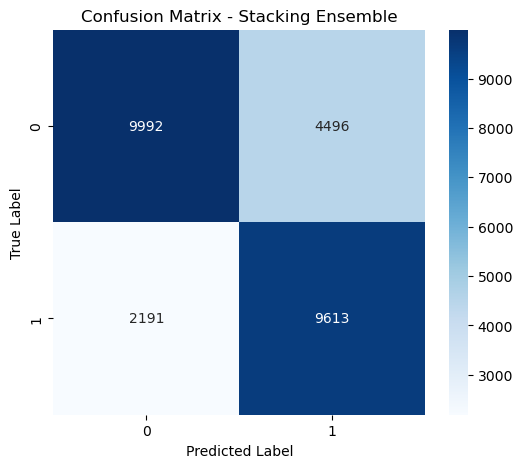

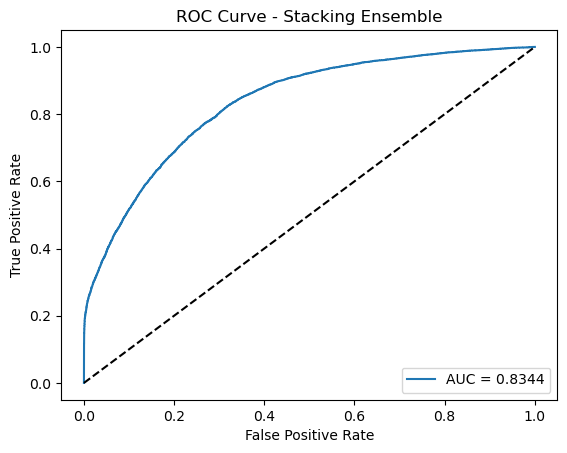

In [105]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# Define the stacking ensemble
stacking_model = StackingClassifier(
    estimators=[
        ('rf', best_rf),
        ('xgb', best_xgb)
    ],
    final_estimator=LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    cv=5,
    n_jobs=-1,
    passthrough=True  # pass original features to meta-learner for more power
)

# Evaluate
results.append(evaluate_model(stacking_model, X_train, X_test, y_train, y_test, "Stacking Ensemble", use_scaled=True))


In [115]:
# Step 1: Select features and scale
input_features = input_df[features.columns]  # match training features
input_features_scaled = scaler.transform(input_features)

# Step 2: Predict fire risk probability
input_df['fire_risk_prob'] = stacking_model.predict_proba(input_features_scaled)[:, 1]

# Step 3: Group by location + time and calculate average fire risk
risk_by_location = (
    input_df
    .groupby(['latitude', 'longitude', 'year', 'month'])['fire_risk_prob']
    .mean()
    .reset_index()
    .sort_values(by='fire_risk_prob', ascending=False)
)

# Step 4: Preview top risky areas with month and year
print(risk_by_location.head())


       latitude  longitude  year  month  fire_risk_prob
25473  36.82670 -118.73030  2024     10        0.825760
25490  36.82760 -118.77440  2024     10        0.819496
25806  36.84035 -118.77349  2024     10        0.817311
25382  36.82200 -118.72220  2024     10        0.814736
25383  36.82204 -118.72236  2024     10        0.814736



Voting Ensemble Performance:
Accuracy: 0.7417
Precision: 0.6744
Recall: 0.8208
F1 Score: 0.7405
AUC: 0.8210

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.68      0.74     14488
           1       0.67      0.82      0.74     11804

    accuracy                           0.74     26292
   macro avg       0.75      0.75      0.74     26292
weighted avg       0.76      0.74      0.74     26292



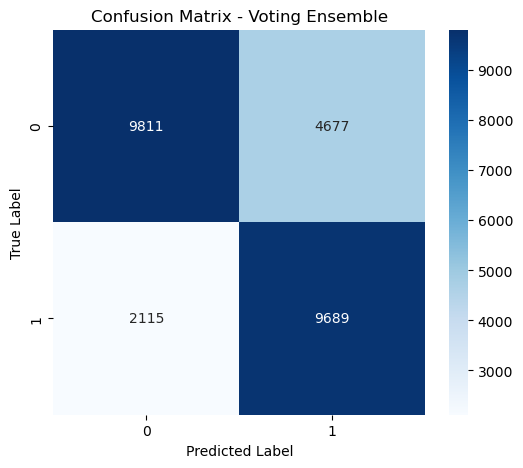

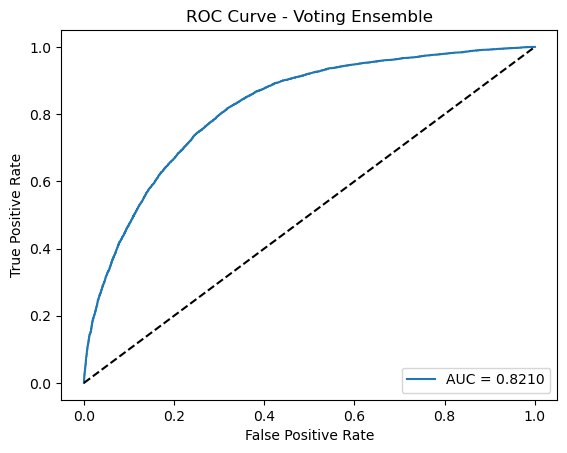

In [109]:
from sklearn.ensemble import VotingClassifier

# Build a soft voting classifier using your tuned top 2 models
voting_model = VotingClassifier(
    estimators=[
        ('rf', best_rf),
        ('xgb', best_xgb)
    ],
    voting='soft'  # soft voting uses predict_proba()
)

# Evaluate it
results.append(evaluate_model(voting_model, X_train, X_test, y_train, y_test, "Voting Ensemble", use_scaled=False))


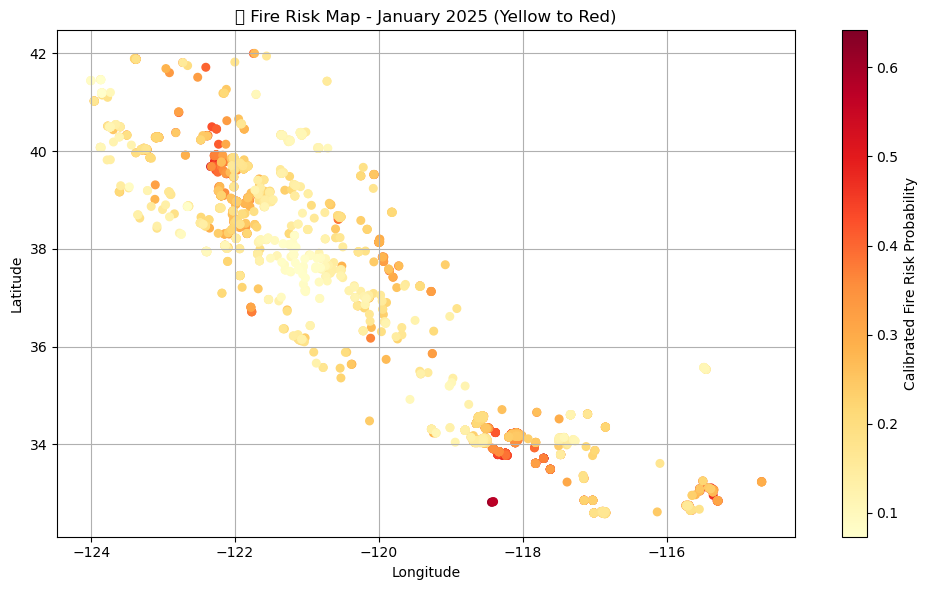

In [119]:
# Example: January 2025
subset = risk_by_location[(risk_by_location['year'] == 2025) & (risk_by_location['month'] == 1)]

plt.figure(figsize=(10, 6))
plt.scatter(subset['longitude'], subset['latitude'],
            c=subset['fire_risk_prob'], cmap='YlOrRd', s=30)
plt.colorbar(label='Calibrated Fire Risk Probability')
plt.title("🔥 Fire Risk Map - January 2025 (Yellow to Red)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.tight_layout()
plt.show()
